[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanyepesp/ISIS-4825_202610_IMAGENES_Y_VISION/blob/main/Laboratorio_08/Taller/MISIS4825_Laboratorio08_Taller.ipynb)

# Laboratorio 08 - Taller: Redes Neuronales Convolucionales

En este taller profundizaremos en el diseño, implementación y optimización de redes neuronales convolucionales (CNNs) para tareas de clasificación de imágenes. Utilizaremos el conjunto de datos **Four Genre Movie Poster Images**, el cual contiene pósters de películas organizados en cuatro géneros.

El objetivo principal es construir y optimizar modelos de CNN propios que permitan distinguir entre las diferentes clases presentes en el dataset. La idea es que se guíen del desarrollo con el notebook de práctica.

## Instrucciones del Taller

### 1. Diseño y Construcción de una Red Convolucional Propia

- **Arquitectura de la CNN:**  
  Diseñe una arquitectura de CNN personalizada utilizando Keras. Explique las decisiones tomadas en cada etapa, tales como:
  - Número y tipo de capas convolucionales.
  - Tamaño de los filtros y kernels.
  - Elección de las capas de pooling (MaxPooling2D, AveragePooling2D, etc.).
  - Funciones de activación utilizadas (por ejemplo, ReLU).
  - Implementación de técnicas de regularización (por ejemplo, Dropout) para prevenir el sobreajuste.
- **Preprocesamiento de Datos:**  
  Realice el preprocesamiento adecuado de los datos, como reescalado (normalización) y data augmentation, y divida el conjunto de datos en entrenamiento, validación y test.
- **Documentación:**  
  Justifique las decisiones de diseño y preprocesamiento, explicando cómo cada elección impacta el rendimiento del modelo.

### 2. Experimentación y Optimización del Modelo

- **Ajuste de Arquitectura y Hiperparámetros:**  
  Realice experimentos modificando la arquitectura base de su CNN. Algunas ideas incluyen:
  - Variar el número de capas convolucionales y neuronas en las capas densas.
  - Ajustar los parámetros de las capas de pooling.
  - Modificar la tasa de Dropout, la tasa de aprendizaje, y el tamaño del batch.
- **Evaluación de Resultados:**  
  Documente y analice los resultados obtenidos en cada experimento. Utilice métricas como precisión, recall, F1-score y la matriz de confusión para evaluar el desempeño.
- **Visualización:**  
  Genere gráficos que muestren la evolución de la precisión y la pérdida durante el entrenamiento, así como las matrices de confusión para comparar las distintas configuraciones.

### 3. Análisis y Discusión de Resultados

- **Comparación de Experimentos:**  
  Compare el rendimiento de su modelo base con las variantes experimentales. Analice y discuta:
  - ¿Qué impacto tiene la profundidad de la red y el número de filtros en la capacidad de aprendizaje?
  - ¿Cómo influyen las técnicas de regularización (por ejemplo, Dropout) en la capacidad de generalización del modelo?
  - ¿Qué mejoras adicionales se podrían implementar para optimizar aún más el rendimiento del modelo?
- **Reflexión:**  
  Plantee conclusiones y proponga futuras líneas de trabajo o posibles ajustes en la arquitectura que podrían mejorar la clasificación.

**Datos:** [Four Genre Movie Poster Images](https://www.kaggle.com/datasets/zulkarnainsaurav/four-genre-movie-poster-images)


---

# **Taller 8**

* Nicolas Rozo Fajardo - 202112920
* Santiago Martínez Novoa - 202112020

# **0. Exploración básica de datos**

In [1]:
import matplotlib.pyplot as plt
import random
import cv2
import os

In [2]:
DATA_DIR = "../data"

In [3]:
action_dir = os.path.join(DATA_DIR, "Action")
comedy_dir = os.path.join(DATA_DIR, "Comedy")
horror_dir = os.path.join(DATA_DIR, "Horror")
romance_dir = os.path.join(DATA_DIR, "Romance")

In [4]:
action_images = os.listdir(action_dir)
comedy_images = os.listdir(comedy_dir)
horror_images = os.listdir(horror_dir)
romance_images = os.listdir(romance_dir)

In [6]:
print("NUMBER OF IMAGES:\n")
print(f"ACTION: {len(action_images)}")
print(f"COMEDY: {len(comedy_images)}")
print(f"HORROR: {len(horror_images)}")
print(f"ROMANCE: {len(romance_images)}")

NUMBER OF IMAGES:

ACTION: 337
COMEDY: 321
HORROR: 398
ROMANCE: 269


In [7]:
categories = [
    c for c in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, c))
]

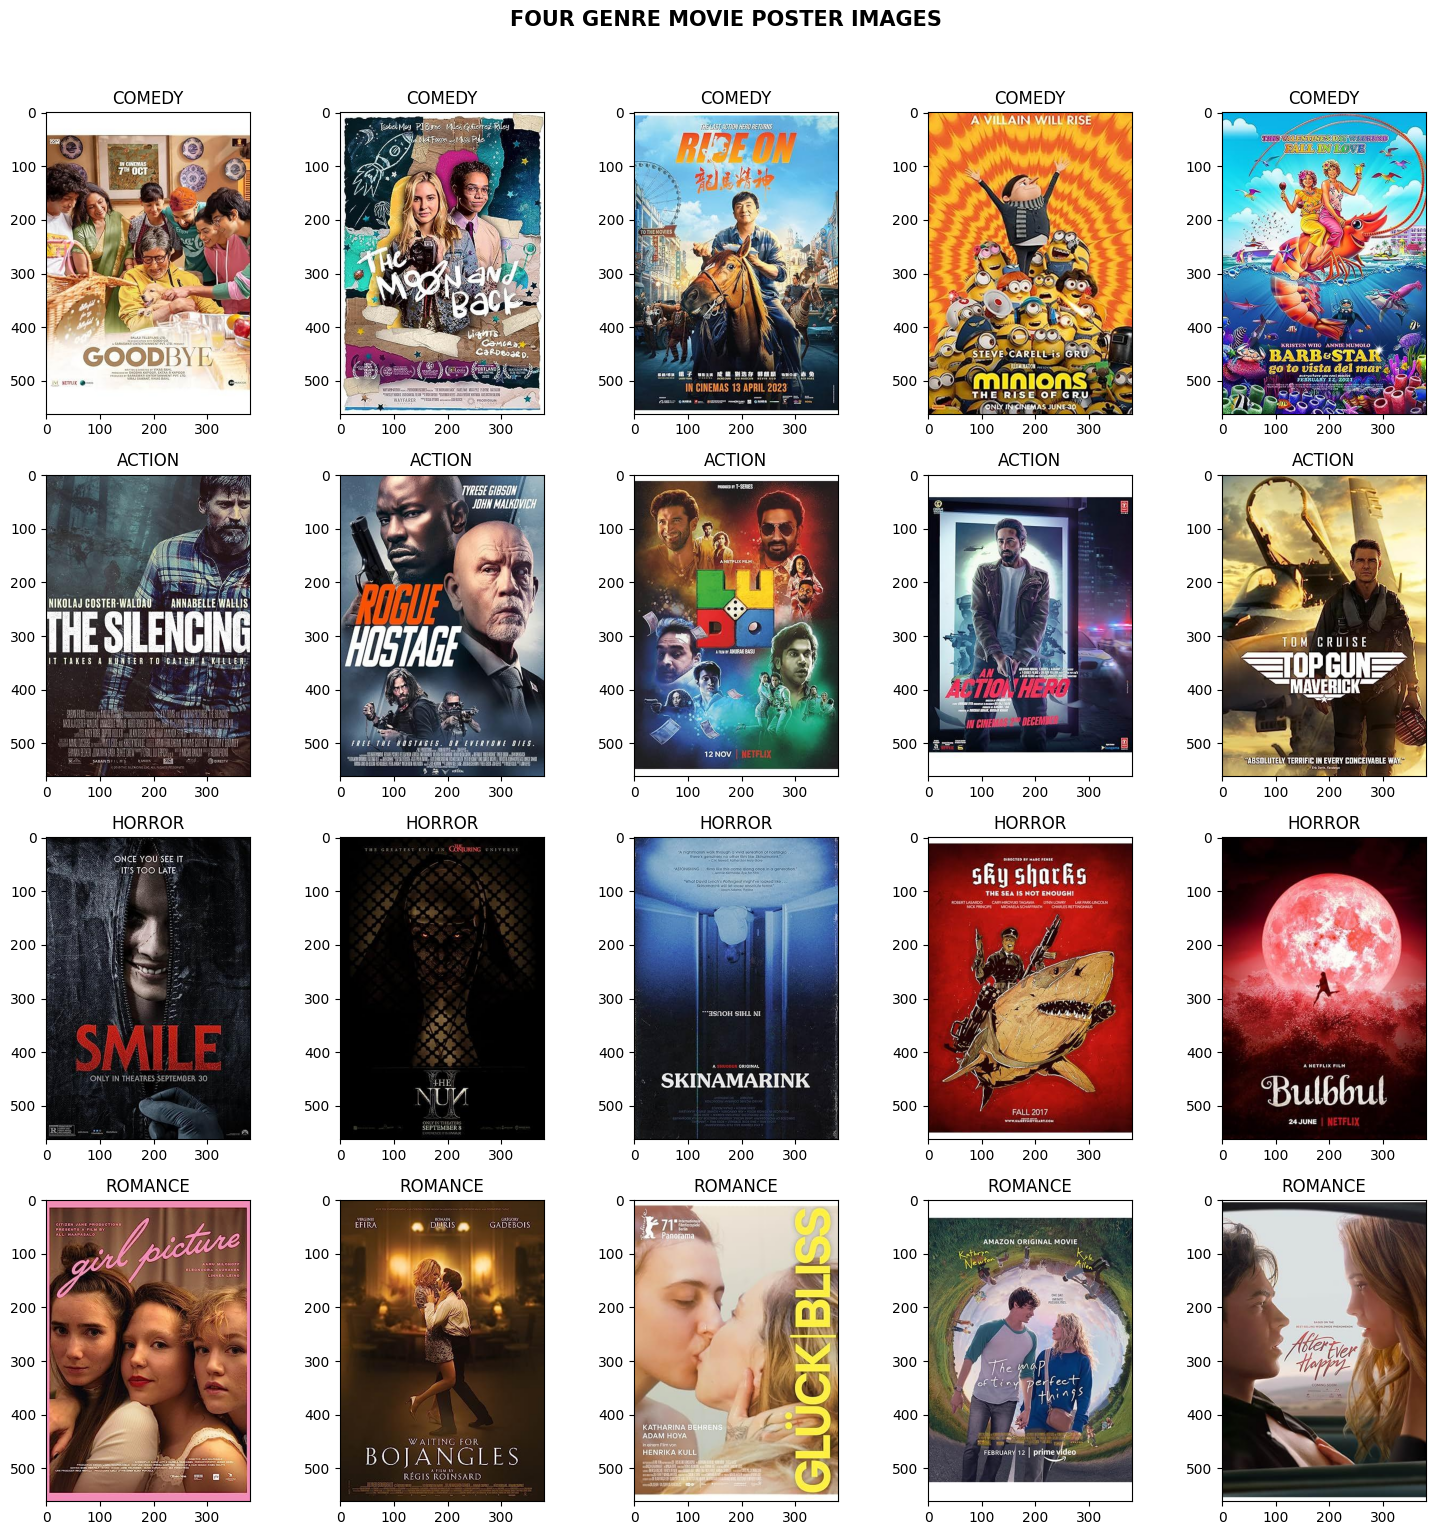

In [10]:
plt.figure(figsize = (15, 15))
plt.suptitle("FOUR GENRE MOVIE POSTER IMAGES", fontsize = 15, fontweight = "bold", y = 1.02)
for i, category in enumerate(categories):

    folder = os.path.join(DATA_DIR, category)
    images = os.listdir(folder)

    for j in range(5):  

        img_name = random.choice(images)
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(len(categories), 5, i * 5 + j + 1)
        plt.imshow(img)
        plt.title(category.upper())

plt.tight_layout()
plt.show()

In [12]:
dirs = {
    "ACTION": action_dir,
    "COMEDY": comedy_dir,
    "HORROR": horror_dir,
    "ROMANCE": romance_dir
}

In [14]:
print("IMAGE SIZE COUNT:\n")

for genre, path in dirs.items():

    sizes = {}

    for img_name in os.listdir(path):

        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        
        if img is not None:
            
            h, w = img.shape[:2]
            shape_str = f"{w}x{h}"
            
            sizes[shape_str] = sizes.get(shape_str, 0) + 1
    
    print(f"{genre}:")
    for size, count in sizes.items():
        print(f"  - {size}: {count} images")
    print("-" * 20)

IMAGE SIZE COUNT:

ACTION:
  - 380x562: 337 images
--------------------
COMEDY:
  - 380x562: 321 images
--------------------
HORROR:
  - 380x562: 398 images
--------------------
ROMANCE:
  - 380x562: 269 images
--------------------
